In [137]:
import pandas as pd
import numpy as np
import torch
import torch.nn
from torch.utils.data import Dataset, DataLoader
import json
import CLSTM
import GetCausal
import importlib
importlib.reload(GetCausal)
importlib.reload(CLSTM)

<module 'CLSTM' from '/Users/lizzy/d2l-en/pytorch/PyTorch&LSTM CryptoData/CLSTM.py'>

In [125]:
data=pd.read_csv('Processed_Crypto_1ms.csv')
print(data.columns)
symbols = ['ADAUSDT', 'BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT', 'WBTCUSDT']
partitioned_inputs= {}
for symbol in symbols:
    mid_price = (data[f'BestAskPrice_{symbol}'] + data[f'BestBidPrice_{symbol}']) / 2
    data[f'price_{symbol}'] = data[f'price_{symbol}'].fillna(mid_price)
    data[f'log_return_{symbol}'] = np.log(data[f'price_{symbol}']).diff().fillna(0)

Index(['Date_s', 'BestAskPrice_ADAUSDT', 'BestAskPrice_BTCUSDT',
       'BestAskPrice_DOGEUSDT', 'BestAskPrice_ETHUSDT', 'BestAskPrice_LTCUSDT',
       'BestAskPrice_SOLUSDT', 'BestAskPrice_WBTCUSDT', 'BestBidPrice_ADAUSDT',
       'BestBidPrice_BTCUSDT', 'BestBidPrice_DOGEUSDT', 'BestBidPrice_ETHUSDT',
       'BestBidPrice_LTCUSDT', 'BestBidPrice_SOLUSDT', 'BestBidPrice_WBTCUSDT',
       'price_ADAUSDT', 'price_BTCUSDT', 'price_DOGEUSDT', 'price_ETHUSDT',
       'price_LTCUSDT', 'price_SOLUSDT', 'price_WBTCUSDT'],
      dtype='object')


In [ ]:
import numpy as np
import pandas as pd
import torch

def prepare_lstm_data_volume_1s(
    data: pd.DataFrame,
    seq_length: int = 10,           
    predict_horizon: int = 1,       
    volume_col: str = 'volume_ETHUSDT',  
    train_ratio: float = 0.7,
    val_ratio: float = 0.15
):

    data = data.copy()
    data['target_volume'] = data[volume_col].shift(-predict_horizon)
    
    features = data[['log_return_BTCUSDT', 'log_return_ETHUSDT', 'target_volume']].dropna()

    input_cols = ['log_return_BTCUSDT', 'log_return_ETHUSDT']
    data_matrix = features[input_cols].values
    target_vector = features['target_volume'].values
    
    xs, ys = [], []
    for i in range(len(data_matrix) - seq_length):
   
        x = data_matrix[i : i + seq_length]

        y = target_vector[i + seq_length - 1 + predict_horizon]  # 注意偏移
        
        xs.append(x)
        ys.append(y)
    
    X = np.array(xs)          # (n_samples, seq_length, 2)
    y = np.array(ys)          # (n_samples,)
    
  
    total_n = len(X)
    train_end = int(total_n * train_ratio)
    val_end = int(total_n * (train_ratio + val_ratio))
    
    def to_tensor(x_arr, y_arr):
        return (
            torch.tensor(x_arr, dtype=torch.float32),
            torch.tensor(y_arr, dtype=torch.float32).view(-1, 1)  # (batch, 1)
        )

    trainX, trainY = to_tensor(X[:train_end], y[:train_end])
    valX, valY     = to_tensor(X[train_end:val_end], y[train_end:val_end])
    testX, testY   = to_tensor(X[val_end:], y[val_end:])
    
    return trainX, trainY, valX, valY, testX, testY



1. get causaity based on PCMCI for 2 features with 10 window
2. plot line chart of causal strength for 2 features with 10 window
Drawing causality heatmap for crypto_data...
Plot saved to crypto_data_causality_structure.png


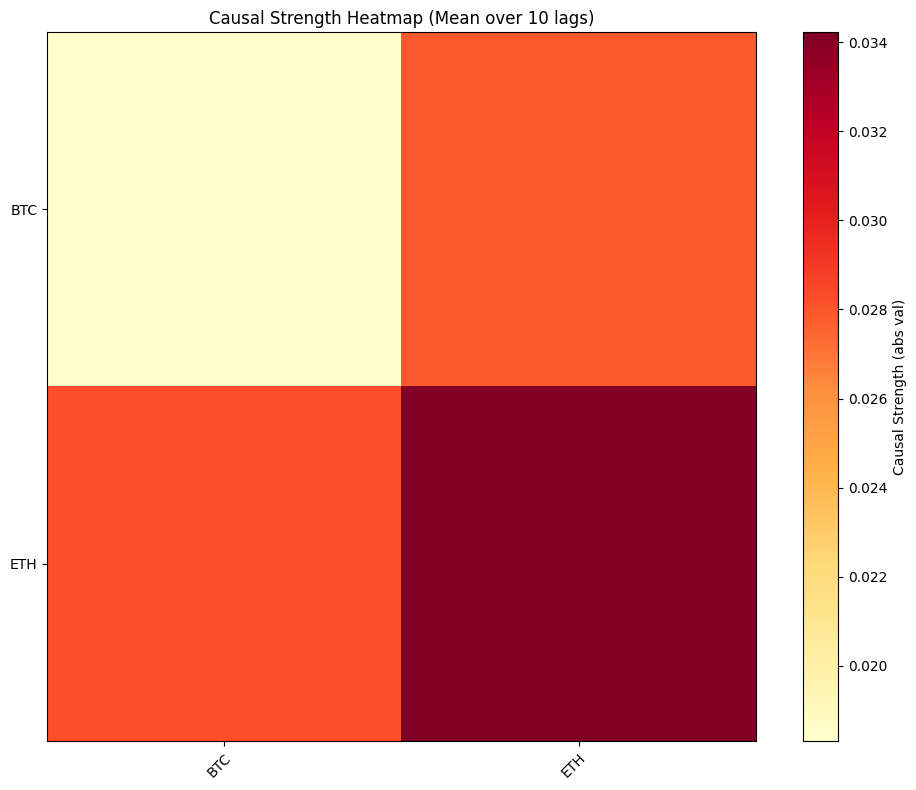

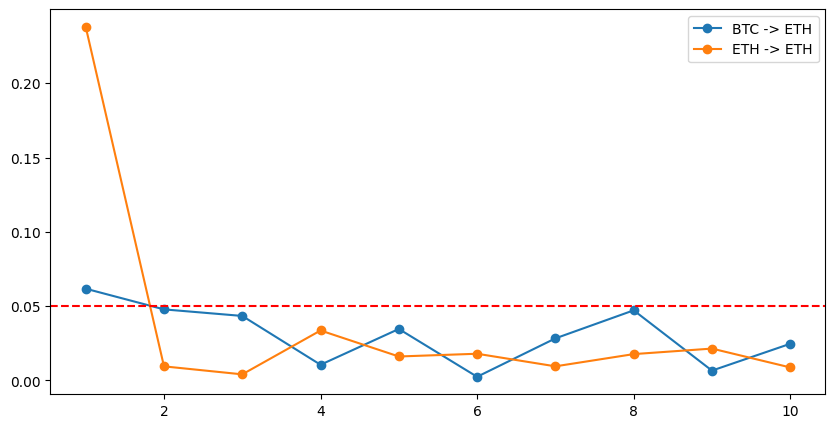

3. group causal drivers for the same causal activation time
5. get group 1 trees


In [ ]:
combined_data = np.column_stack((
    data['log_return_BTCUSDT'].values, 
    data['log_return_ETHUSDT'].values
))

split_idx = int(len(combined_data) * 0.8)
train_data_2d = combined_data[:split_idx]  


causal_analyzer = GetCausal.CausalPrecursors(
    var_names=['BTC', 'ETH'],
    window=10,
    num_features=2
)

C=causal_analyzer.__call__(train_data_2d)


In [ ]:

tau = '1' 


num_nodes = len(C.group_nodes[tau]['1']) + len(C.group_nodes[tau]['2']) # 总节点数
num_child_nodes = C.group_num_chid_nodes[tau]
input_idx = C.group_input_idx[tau]
child_state_idx = C.group_child_state_idx[tau]


model = CLSTM.CLSTM(
    num_nodes=len(input_idx), 
    num_hiddens=64,            
    num_child_nodes=num_child_nodes, 
    input_idx=input_idx, 
    child_state_idx=child_state_idx, 
    input_len=10,               
    batch_size=32
)

print("CLSTM initialized！")

CLSTM 模型初始化成功！


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

batch_size = 256

train_loader = DataLoader(TensorDataset(trainX, trainY), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(valX, valY), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(testX, testY), batch_size=batch_size, shuffle=False)

epochs = 100

optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = torch.nn.HuberLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True
)

best_val_loss = float('inf')
patience = 10
counter = 0

train_losses = []
val_losses = []
test_losses = []

print("Starting training with Train/Val/Test monitoring...")
for epoch in range(epochs):

    model.train()
    running_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_running = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            val_running += loss.item() * xb.size(0)

    val_loss = val_running / len(val_loader.dataset)
    val_losses.append(val_loss)

    test_running = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            test_running += loss.item() * xb.size(0)

    test_loss = test_running / len(test_loader.dataset)
    test_losses.append(test_loss)

    # scheduler
    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train: {train_loss:.8f} | "
        f"Val: {val_loss:.8f} | "
        f"Test: {test_loss:.8f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(torch.load("best_model.pth"))

print(f"\nBest Validation Loss: {best_val_loss:.8f}")
print(f"Final Test Loss: {test_losses[-1]:.8f}")

Starting training with Train/Val/Test monitoring...
Epoch [1/100] | Train: 0.00271449 | Val: 0.00073998 | Test: 0.00074246
Epoch [2/100] | Train: 0.00057871 | Val: 0.00000019 | Test: 0.00000014
Epoch [3/100] | Train: 0.00009835 | Val: 0.00010301 | Test: 0.00010203
Epoch [4/100] | Train: 0.00002864 | Val: 0.00002327 | Test: 0.00002367
Epoch [5/100] | Train: 0.00001831 | Val: 0.00000033 | Test: 0.00000026
Epoch [6/100] | Train: 0.00000422 | Val: 0.00000286 | Test: 0.00000268
Epoch [7/100] | Train: 0.00000104 | Val: 0.00000105 | Test: 0.00000110
Epoch 00008: reducing learning rate of group 0 to 2.5000e-04.
Epoch [8/100] | Train: 0.00000069 | Val: 0.00000075 | Test: 0.00000064
Epoch [9/100] | Train: 0.00000049 | Val: 0.00000029 | Test: 0.00000022
Epoch [10/100] | Train: 0.00000028 | Val: 0.00000017 | Test: 0.00000013
Epoch [11/100] | Train: 0.00000028 | Val: 0.00000023 | Test: 0.00000017
Epoch [12/100] | Train: 0.00000026 | Val: 0.00000023 | Test: 0.00000017
Epoch [13/100] | Train: 0.00000

In [147]:
pred = model(testX).cpu().detach().numpy().flatten()
true = testY.cpu().numpy().flatten()

median_pred = np.median(pred)
direction_acc_median = np.mean(
    (pred > median_pred) == (true > median_pred)
)
print(f"Above/below median direction acc: {direction_acc_median:.4f}")


Above/below median direction acc: 0.4991


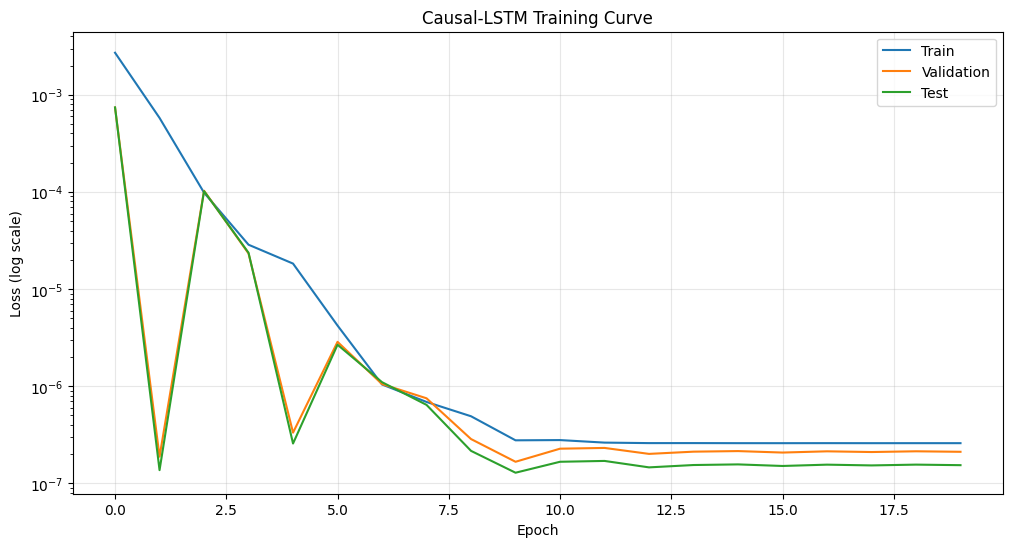

In [144]:
plt.figure(figsize=(12,6))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.plot(test_losses,label='Test' )

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Causal-LSTM Training Curve")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Merged shape (small sample): (32642, 95)
                         price_bnb  qty_bnb  quote_qty_bnb is_buyer_maker_bnb  \
timestamp                                                                       
2023-07-15 00:00:00.025        NaN      NaN            NaN                NaN   
2023-07-15 00:00:00.036     247.89     0.03         7.4367               True   
2023-07-15 00:00:00.068     247.89     0.03         7.4367               True   
2023-07-15 00:00:00.074     247.89     0.03         7.4367               True   
2023-07-15 00:00:00.111        NaN      NaN            NaN                NaN   

                         best_bid_price_bnb  best_bid_qty_bnb  \
timestamp                                                       
2023-07-15 00:00:00.025                 NaN               NaN   
2023-07-15 00:00:00.036              247.89            203.77   
2023-07-15 00:00:00.068              247.89            203.74   
2023-07-15 00:00:00.074              247.89            203.71   
2

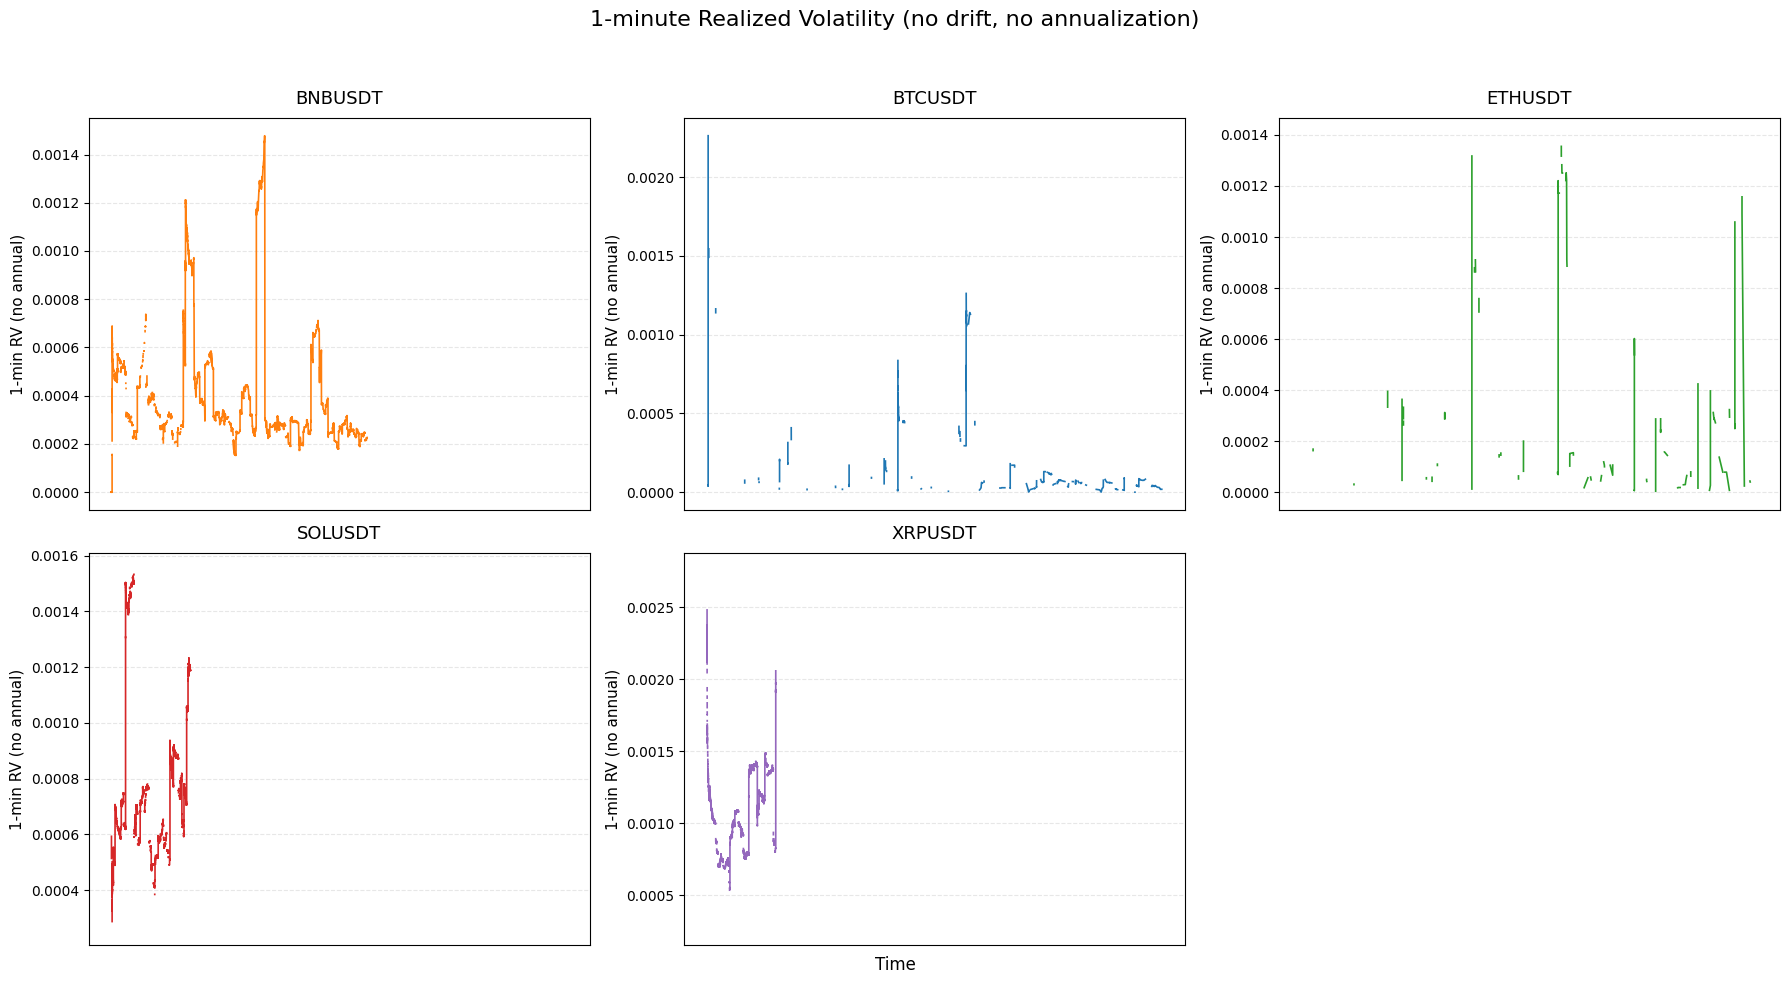

bnb 19999
btc 8164
eth 9842
sol 19999
xrp 19999


BNB clean samples for training: 7070
BTC clean samples for training: 5646
ETH clean samples for training: 7573
SOL clean samples for training: 6535
XRP clean samples for training: 5752


ETH clean samples for training: 7573

 MODEL eth_base | Features: 9

Using features: ['spread_eth_norm', 'depth_eth_norm', 'imbalance_eth', 'rel_spread_eth_norm', 'mid_price_eth_norm', 'log_ret_eth', 'net_oflow_1min_eth', 'vol_1min_eth', 'funding_rate_eth']
Train samples:  4505 | Val:  1501 | Test:  1503
[  1]  Train: 2.003184  |  Val: 0.959195  | LR: 5.00e-05
[  2]  Train: 1.596083  |  Val: 0.851763  | LR: 5.00e-05
[  3]  Train: 1.278204  |  Val: 0.839095  | LR: 5.00e-05
[  4]  Train: 1.062243  |  Val: 0.805683  | LR: 5.00e-05
[  5]  Train: 0.940142  |  Val: 0.792233  | LR: 5.00e-05
[  6]  Train: 0.850364  |  Val: 0.791319  | LR: 5.00e-05
[  7]  Train: 0.786235  |  Val: 0.798112  | LR: 5.00e-05
[  8]  Train: 0.767201  |  Val: 0.796828  | LR: 5.00e-05
[  9]  Train: 0.732925  |  Val: 0.791255  | LR: 5.00e-05
[ 10]  Train: 0.707086  |  Val: 0.794707  | LR: 5.00e-05
[ 11]  Train: 0.708139  |  Val: 0.792280  | LR: 5.00e-05
[ 12]  Train: 0.686744  |  Val: 0.791021  | LR: 5.00e-05
[ 13]  Tra

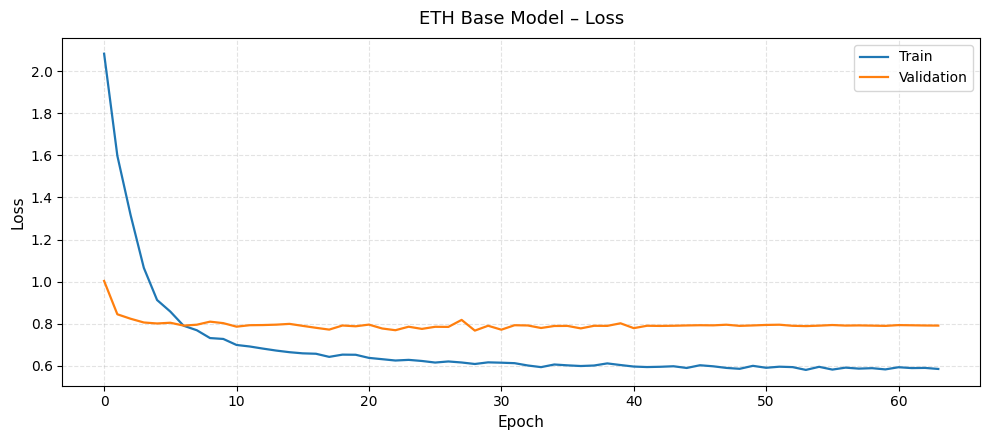

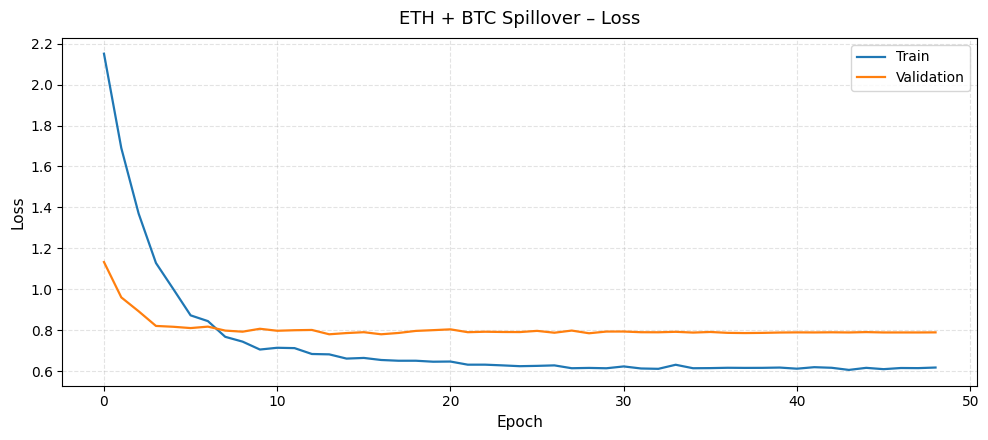

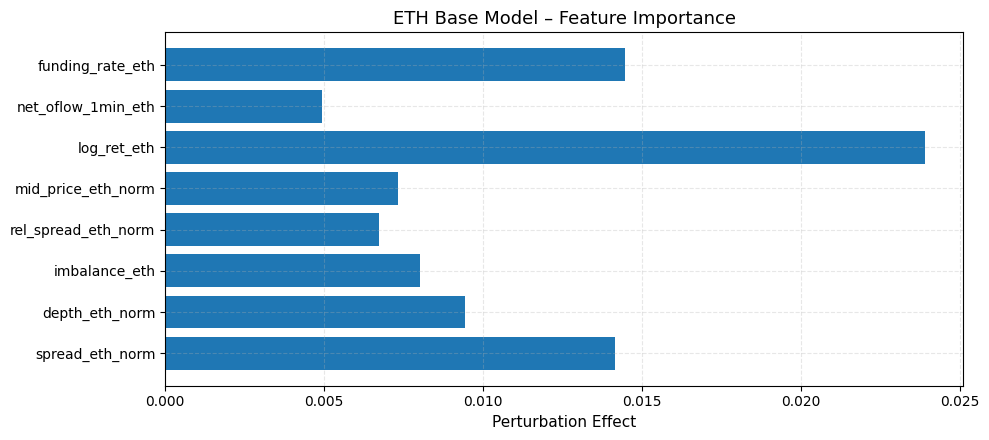

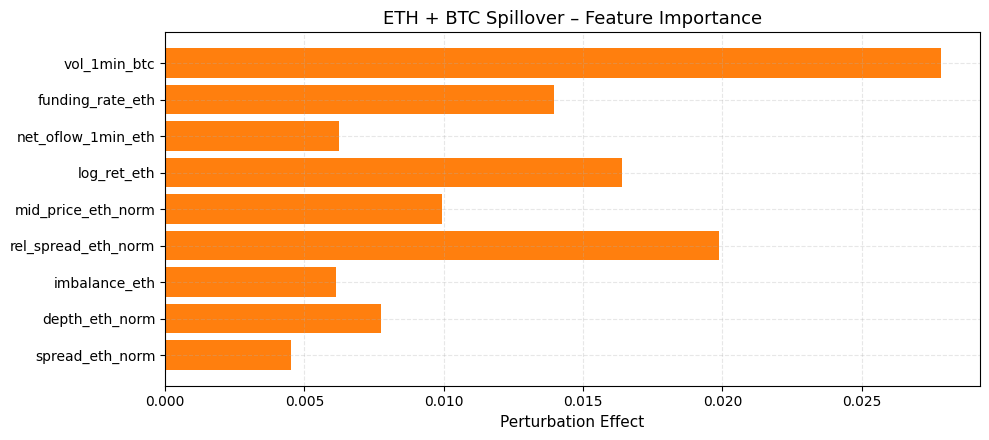